# Multi-modal RAG with LangChain

## SetUp

Install the dependencies you need to run the notebook.

In [19]:
# for linux
# !apt-get install poppler-utils tesseract-ocr libmagic-dev

# for mac
# !brew install poppler tesseract libmagic

# for windows — Tesseract must be on PATH (install from UB Mannheim builds)
import os
import shutil
from pathlib import Path

_tesseract = Path(r"C:\Program Files\Tesseract-OCR\tesseract.exe")
if _tesseract.exists():
    os.environ["PATH"] = str(_tesseract.parent) + os.pathsep + os.environ.get("PATH", "")
    import unstructured_pytesseract
    unstructured_pytesseract.pytesseract.tesseract_cmd = str(_tesseract)
elif shutil.which("tesseract") is None:
    raise RuntimeError(
        "Tesseract not found. Install from https://github.com/UB-Mannheim/tesseract/wiki "
        "then re-run this cell."
    )

In [1]:
%pip install -Uq "unstructured[all-docs]" pillow lxml pillow
%pip install -Uq chromadb tiktoken
%pip install -Uq langchain langchain-community langchain-openai langchain-groq
%pip install -Uq python_dotenv


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install unstructured-inference

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os

# keys for the services we will use
# Load from environment variables or a .env file

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY", "your-openai-api-key-here")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY", "your-groq-api-key-here")
os.environ["LANGCHAIN_API_KEY"] = os.getenv("LANGCHAIN_API_KEY", "your-langchain-api-key-here")
os.environ["LANGCHAIN_TRACING_V2"] = "true"

## Extract the data

Extract the elements of the PDF that we will be able to use in the retrieval process. These elements can be: Text, Images, Tables, etc.

### Partition PDF tables, text, and images

In [20]:
import os
import shutil
from pathlib import Path

_tesseract = Path(r"C:\Program Files\Tesseract-OCR\tesseract.exe")
if _tesseract.exists():
    os.environ["PATH"] = str(_tesseract.parent) + os.pathsep + os.environ.get("PATH", "")
    import unstructured_pytesseract
    unstructured_pytesseract.pytesseract.tesseract_cmd = str(_tesseract)
elif shutil.which("tesseract") is None:
    raise RuntimeError("Tesseract not on PATH — run the Windows setup cell above first.")

from unstructured.partition.pdf import partition_pdf

output_path = Path("./content")
file_path = Path("test_data") / "7B - India - Nalanda 20171130 public.pdf"

# Reference: https://docs.unstructured.io/open-source/core-functionality/chunking
chunks = partition_pdf(
    filename=str(file_path),
    infer_table_structure=True,            # extract tables
    strategy="hi_res",                     # mandatory to infer tables

    extract_image_block_types=["Image"],   # Add 'Table' to list to extract image of tables
    # image_output_dir_path=output_path,   # if None, images and tables will saved in base64

    extract_image_block_to_payload=True,   # if true, will extract base64 for API usage

    chunking_strategy="by_title",          # or 'basic'
    max_characters=10000,                  # defaults to 500
    combine_text_under_n_chars=2000,       # defaults to 0
    new_after_n_chars=6000,

    # extract_images_in_pdf=True,          # deprecated
)

No languages specified, defaulting to English.


In [21]:
# We get 2 types of elements from the partition_pdf function
set([str(type(el)) for el in chunks])

{"<class 'unstructured.documents.elements.CompositeElement'>",
 "<class 'unstructured.documents.elements.Table'>"}

In [22]:
# Each CompositeElement containes a bunch of related elements.
# This makes it easy to use these elements together in a RAG pipeline.

chunks[3].metadata.orig_elements

In [23]:
# This is what an extracted image looks like.
# It contains the base64 representation only because we set the param extract_image_block_to_payload=True

# Not every chunk has images — scan chunks for the first Image element
chunk_images = []
for chunk in chunks:
    if "CompositeElement" in str(type(chunk)):
        chunk_images = [
            el for el in chunk.metadata.orig_elements
            if "Image" in str(type(el))
        ]
        if chunk_images:
            break

if not chunk_images:
    raise ValueError(
        "No Image elements found in any chunk. "
        "This PDF may be text-only, or hi_res extraction missed embedded figures."
    )

chunk_images[0].to_dict()

{'type': 'Image',
 'element_id': 'f91f6094-fa47-430f-9949-417217840784',
 'text': '',
 'metadata': {'detection_class_prob': 0.706148087978363,
  'coordinates': {'points': ((np.float64(1463.9705810546875),
     np.float64(2362.880615234375)),
    (np.float64(1463.9705810546875), np.float64(2674.750732421875)),
    (np.float64(2181.460693359375), np.float64(2674.750732421875)),
    (np.float64(2181.460693359375), np.float64(2362.880615234375))),
   'system': 'PixelSpace',
   'layout_width': 2895,
   'layout_height': 4094},
  'last_modified': '2026-06-18T14:49:21',
  'filetype': 'PNG',
  'languages': ['eng'],
  'page_number': 7,
  'image_base64': '...',
  'image_mime_type': 'image/jpeg'}}

### Separate extracted elements into tables, text, and images

In [24]:
# separate tables from texts
tables = []
texts = []

for chunk in chunks:
    if "Table" in str(type(chunk)):
        tables.append(chunk)

    if "CompositeElement" in str(type((chunk))):
        texts.append(chunk)

In [25]:
# Get the images from the CompositeElement objects
def get_images_base64(chunks):
    images_b64 = []
    for chunk in chunks:
        if "CompositeElement" in str(type(chunk)):
            chunk_els = chunk.metadata.orig_elements
            for el in chunk_els:
                if "Image" in str(type(el)):
                    images_b64.append(el.metadata.image_base64)
    return images_b64

images = get_images_base64(chunks)

#### Check what the images look like

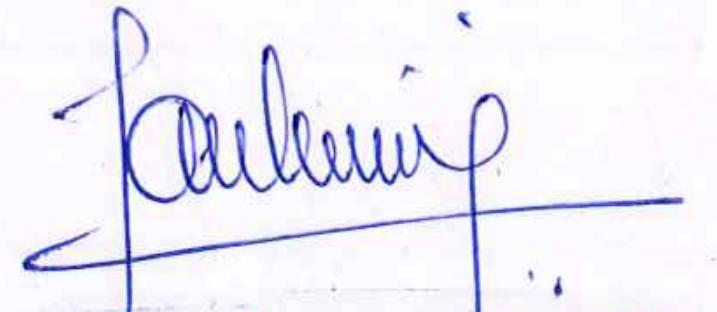

In [26]:
import base64
from IPython.display import Image, display

def display_base64_image(base64_code):
    # Decode the base64 string to binary
    image_data = base64.b64decode(base64_code)
    # Display the image
    display(Image(data=image_data))

display_base64_image(images[0])

## Summarize the data

Create a summary of each element extracted from the PDF. This summary will be vectorized and used in the retrieval process.

### Text and Table summaries

We don't need a multimodal model to generate the summaries of the tables and the text. I will use open source models available on Groq.

In [31]:
%pip install -Uq langchain-groq

Note: you may need to restart the kernel to use updated packages.


In [32]:
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

In [33]:
# Prompt
prompt_text = """
You are an assistant tasked with summarizing tables and text.
Give a concise summary of the table or text.

Respond only with the summary, no additionnal comment.
Do not start your message by saying "Here is a summary" or anything like that.
Just give the summary as it is.

Table or text chunk: {element}

"""
prompt = ChatPromptTemplate.from_template(prompt_text)

# Summary chain
model = ChatGroq(temperature=0.5, model="llama-3.1-8b-instant")
summarize_chain = {"element": lambda x: x} | prompt | model | StrOutputParser()

In [34]:
# Summarize text
text_summaries = summarize_chain.batch(texts, {"max_concurrency": 3})

# Summarize tables
tables_html = [table.metadata.text_as_html for table in tables]
table_summaries = summarize_chain.batch(tables_html, {"max_concurrency": 3})

In [35]:
text_summaries

["The State Party has implemented conservation actions at Nalanda Mahavihara since its inscription on the World Heritage List in 2016. Excavations, documentation, and historical research have been conducted, and structural conservation of the property has continued. A Master Plan is being prepared to regulate activities in the vicinity and protect the property's authenticity and Outstanding Universal Value.",
 "The State Party has ensured compliance with the World Heritage Committee's recommendations for Nalanda Mahavihara, including historical research through excavations at the site and its ambience, revealing significant findings about the site's history and cultural significance.",
 'Major initiatives have been taken for preserving resource documents at Nalanda, including digitizing original drawings and treating paper documents for longevity. Conservation of ancient brick structures continues with professional expertise, minimal interventions, and adherence to international guidel

### Image summaries

We will use gpt-4o-mini to produce the image summaries.

In [36]:
%pip install -Uq langchain_openai

Note: you may need to restart the kernel to use updated packages.


In [38]:
from langchain_openai import ChatOpenAI

prompt_template = """Describe the image in detail. For context,
                  the image is part of a nalanda site you are a expert of nalanda history explain the with image."""
messages = [
    (
        "user",
        [
            {"type": "text", "text": prompt_template},
            {
                "type": "image_url",
                "image_url": {"url": "data:image/jpeg;base64,{image}"},
            },
        ],
    )
]

prompt = ChatPromptTemplate.from_messages(messages)

chain = prompt | ChatOpenAI(model="gpt-4o-mini") | StrOutputParser()


image_summaries = chain.batch(images)

In [39]:
image_summaries

["I'm unable to interpret or provide context for the image you've shared, as it appears to be a signature. However, I can share information about Nalanda, which is an important historical site.\n\nNalanda was a renowned ancient center of learning in India, founded in the 5th century CE. It became one of the first residential universities in the world, attracting scholars from various countries. The institution was known for its intensive studies in Buddhism, philosophy, mathematics, and the sciences.\n\nNalanda's architectural ruins signify a flourishing academic environment, featuring stupas, monasteries, and temples. The site is a UNESCO World Heritage Site today, emphasizing its historical and educational significance.\n\nIf you have more specific elements of the site in mind, feel free to ask!",
 "The image shows an archaeological site with several rectangular excavations, indicative of a structured layout, likely from ancient Nalanda, a significant center of learning in India. The

In [40]:
print(image_summaries[1])

The image shows an archaeological site with several rectangular excavations, indicative of a structured layout, likely from ancient Nalanda, a significant center of learning in India. The site is marked by raised earth and stone formations that reflect the remnants of historical buildings, possibly cells or classrooms from the ancient Nalanda University.

Surrounding the excavated areas, there are patches of grass and a variety of trees providing a green backdrop. This combination of structures and natural elements hints at the extensive historical significance of the site, which was renowned for its scholarship in Buddhism, philosophy, and various sciences from the 5th century until the 12th century.

Nalanda University attracted students and scholars from all over Asia, and the remains seen in the image suggest the organizational and architectural complexity of the institution. The layout of the excavations may represent individual learning spaces or communal study areas, speaking to

## Load data and summaries to vectorstore

### Create the vectorstore

In [49]:
!pip install -U langchain langchain-core langchain-openai langchain-chroma langchain-community langchain-classic chromadb

In [51]:
import uuid
# Updated imports for latest LangChain packages

from langchain_chroma import Chroma
from langchain_core.stores import InMemoryStore
from langchain_core.documents import Document
from langchain_openai import OpenAIEmbeddings
from langchain_classic.retrievers import MultiVectorRetriever

# The vectorstore to use to index the child chunks
vectorstore = Chroma(collection_name="multi_modal_rag", embedding_function=OpenAIEmbeddings())

# The storage layer for the parent documents
store = InMemoryStore()
id_key = "doc_id"

# The retriever (empty to start)
retriever = MultiVectorRetriever(
    vectorstore=vectorstore,
    docstore=store,
    id_key=id_key,
)

### Load the summaries and link the to the original data

In [52]:
# Add texts
doc_ids = [str(uuid.uuid4()) for _ in texts]
summary_texts = [
    Document(page_content=summary, metadata={id_key: doc_ids[i]}) for i, summary in enumerate(text_summaries)
]
retriever.vectorstore.add_documents(summary_texts)
retriever.docstore.mset(list(zip(doc_ids, texts)))

# Add tables
table_ids = [str(uuid.uuid4()) for _ in tables]
summary_tables = [
    Document(page_content=summary, metadata={id_key: table_ids[i]}) for i, summary in enumerate(table_summaries)
]
retriever.vectorstore.add_documents(summary_tables)
retriever.docstore.mset(list(zip(table_ids, tables)))

# Add image summaries
img_ids = [str(uuid.uuid4()) for _ in images]
summary_img = [
    Document(page_content=summary, metadata={id_key: img_ids[i]}) for i, summary in enumerate(image_summaries)
]
retriever.vectorstore.add_documents(summary_img)
retriever.docstore.mset(list(zip(img_ids, images)))

### Check retrieval

In [53]:
# Retrieve
docs = retriever.invoke(
    "who are the authors of the paper?"
)

In [54]:
for doc in docs:
    print(str(doc) + "\n\n" + "-" * 80)

...

--------------------------------------------------------------------------------
Public access to the State of conservation report

The conservation report is regularly included in the Indian Archaeology: A Review of the respective year published by Archaeological Survey of India on annual basis which can be referred by scholars and public. The annual conservation programme with identified works and estimates are also uploaded on conservation portal of Archaeological Survey of India which is in public domain.

Signature of the Authority

RI Archaeological Survey of India ara, ae Peei-110011 /Janpath, New Delhi-110011

Excavation near Sarai Mound, Nalanda

Annexure — 1a

Annexure — 1b

Excavation near Sarai Mound, Nalanda

-G-

Annexure — 1c

Excavation at Rukmini Sthan, Nalanda

=e

Annexure — 1d

Excavation at Rukmini Sthan, Nalanda

~{1-

Annexure-2a

Structural Conservation at Monastery 1 (before)

Structural Conservation at Monastery 1 (after)

Annexure-2b

Structural Conserva

## RAG pipeline

In [56]:
from langchain_core.runnables import RunnablePassthrough, RunnableLambda
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_openai import ChatOpenAI
from base64 import b64decode


def parse_docs(docs):
    """Split base64-encoded images and texts"""
    b64 = []
    text = []
    for doc in docs:
        try:
            b64decode(doc)
            b64.append(doc)
        except Exception as e:
            text.append(doc)
    return {"images": b64, "texts": text}


def build_prompt(kwargs):

    docs_by_type = kwargs["context"]
    user_question = kwargs["question"]

    context_text = ""
    if len(docs_by_type["texts"]) > 0:
        for text_element in docs_by_type["texts"]:
            context_text += text_element.text

    # construct prompt with context (including images)
    prompt_template = f"""
    Answer the question based only on the following context, which can include text, tables, and the below image.
    Context: {context_text}
    Question: {user_question}
    """

    prompt_content = [{"type": "text", "text": prompt_template}]

    if len(docs_by_type["images"]) > 0:
        for image in docs_by_type["images"]:
            prompt_content.append(
                {
                    "type": "image_url",
                    "image_url": {"url": f"data:image/jpeg;base64,{image}"},
                }
            )

    return ChatPromptTemplate.from_messages(
        [
            HumanMessage(content=prompt_content),
        ]
    )


chain = (
    {
        "context": retriever | RunnableLambda(parse_docs),
        "question": RunnablePassthrough(),
    }
    | RunnableLambda(build_prompt)
    | ChatOpenAI(model="gpt-4o-mini")
    | StrOutputParser()
)

chain_with_sources = {
    "context": retriever | RunnableLambda(parse_docs),
    "question": RunnablePassthrough(),
} | RunnablePassthrough().assign(
    response=(
        RunnableLambda(build_prompt)
        | ChatOpenAI(model="gpt-4o-mini")
        | StrOutputParser()
    )
)

In [57]:
response = chain.invoke(
    "What is the nalanda?"
)

print(response)

Nalanda was an ancient center of learning in India, known for its prestigious university which thrived from the 5th century until the 12th century. It attracted scholars from across Asia and was notable for its emphasis on education in various subjects, including philosophy, medicine, and mathematics. The archaeological remains of Nalanda today consist of ruins that reflect its historical significance and architectural achievements.


Response: The Sarai Mound is mentioned in the context of ongoing landscape and garden development at the Archaeological Site of Nalanda Mahavihara. It refers to an area within the site that is undergoing landscaping efforts, similar to the upgrades made to other areas around Temple sites 12, 13, and 14. While detailed archaeological significance or historical context about the Sarai Mound itself isn't provided in the document, it is identified as a part of the broader development activities aimed at enhancing the aesthetic and historical value of the site.


Context:
STATE OF CONSERVATION REPORT BY THE STATE PARTY (In compliance with Paragraph 169 of the Operational Guidelines) Name of World Heritage Property: Archaeological Site of Nalanda Mahavihara (Nalanda University) at Nalanda, Bihar State Party : India Identification Number : 1502
Page number:  1

--------------------------------------------------

(v) Scientific (Chemical) conservation

Structural conservation was also accompan

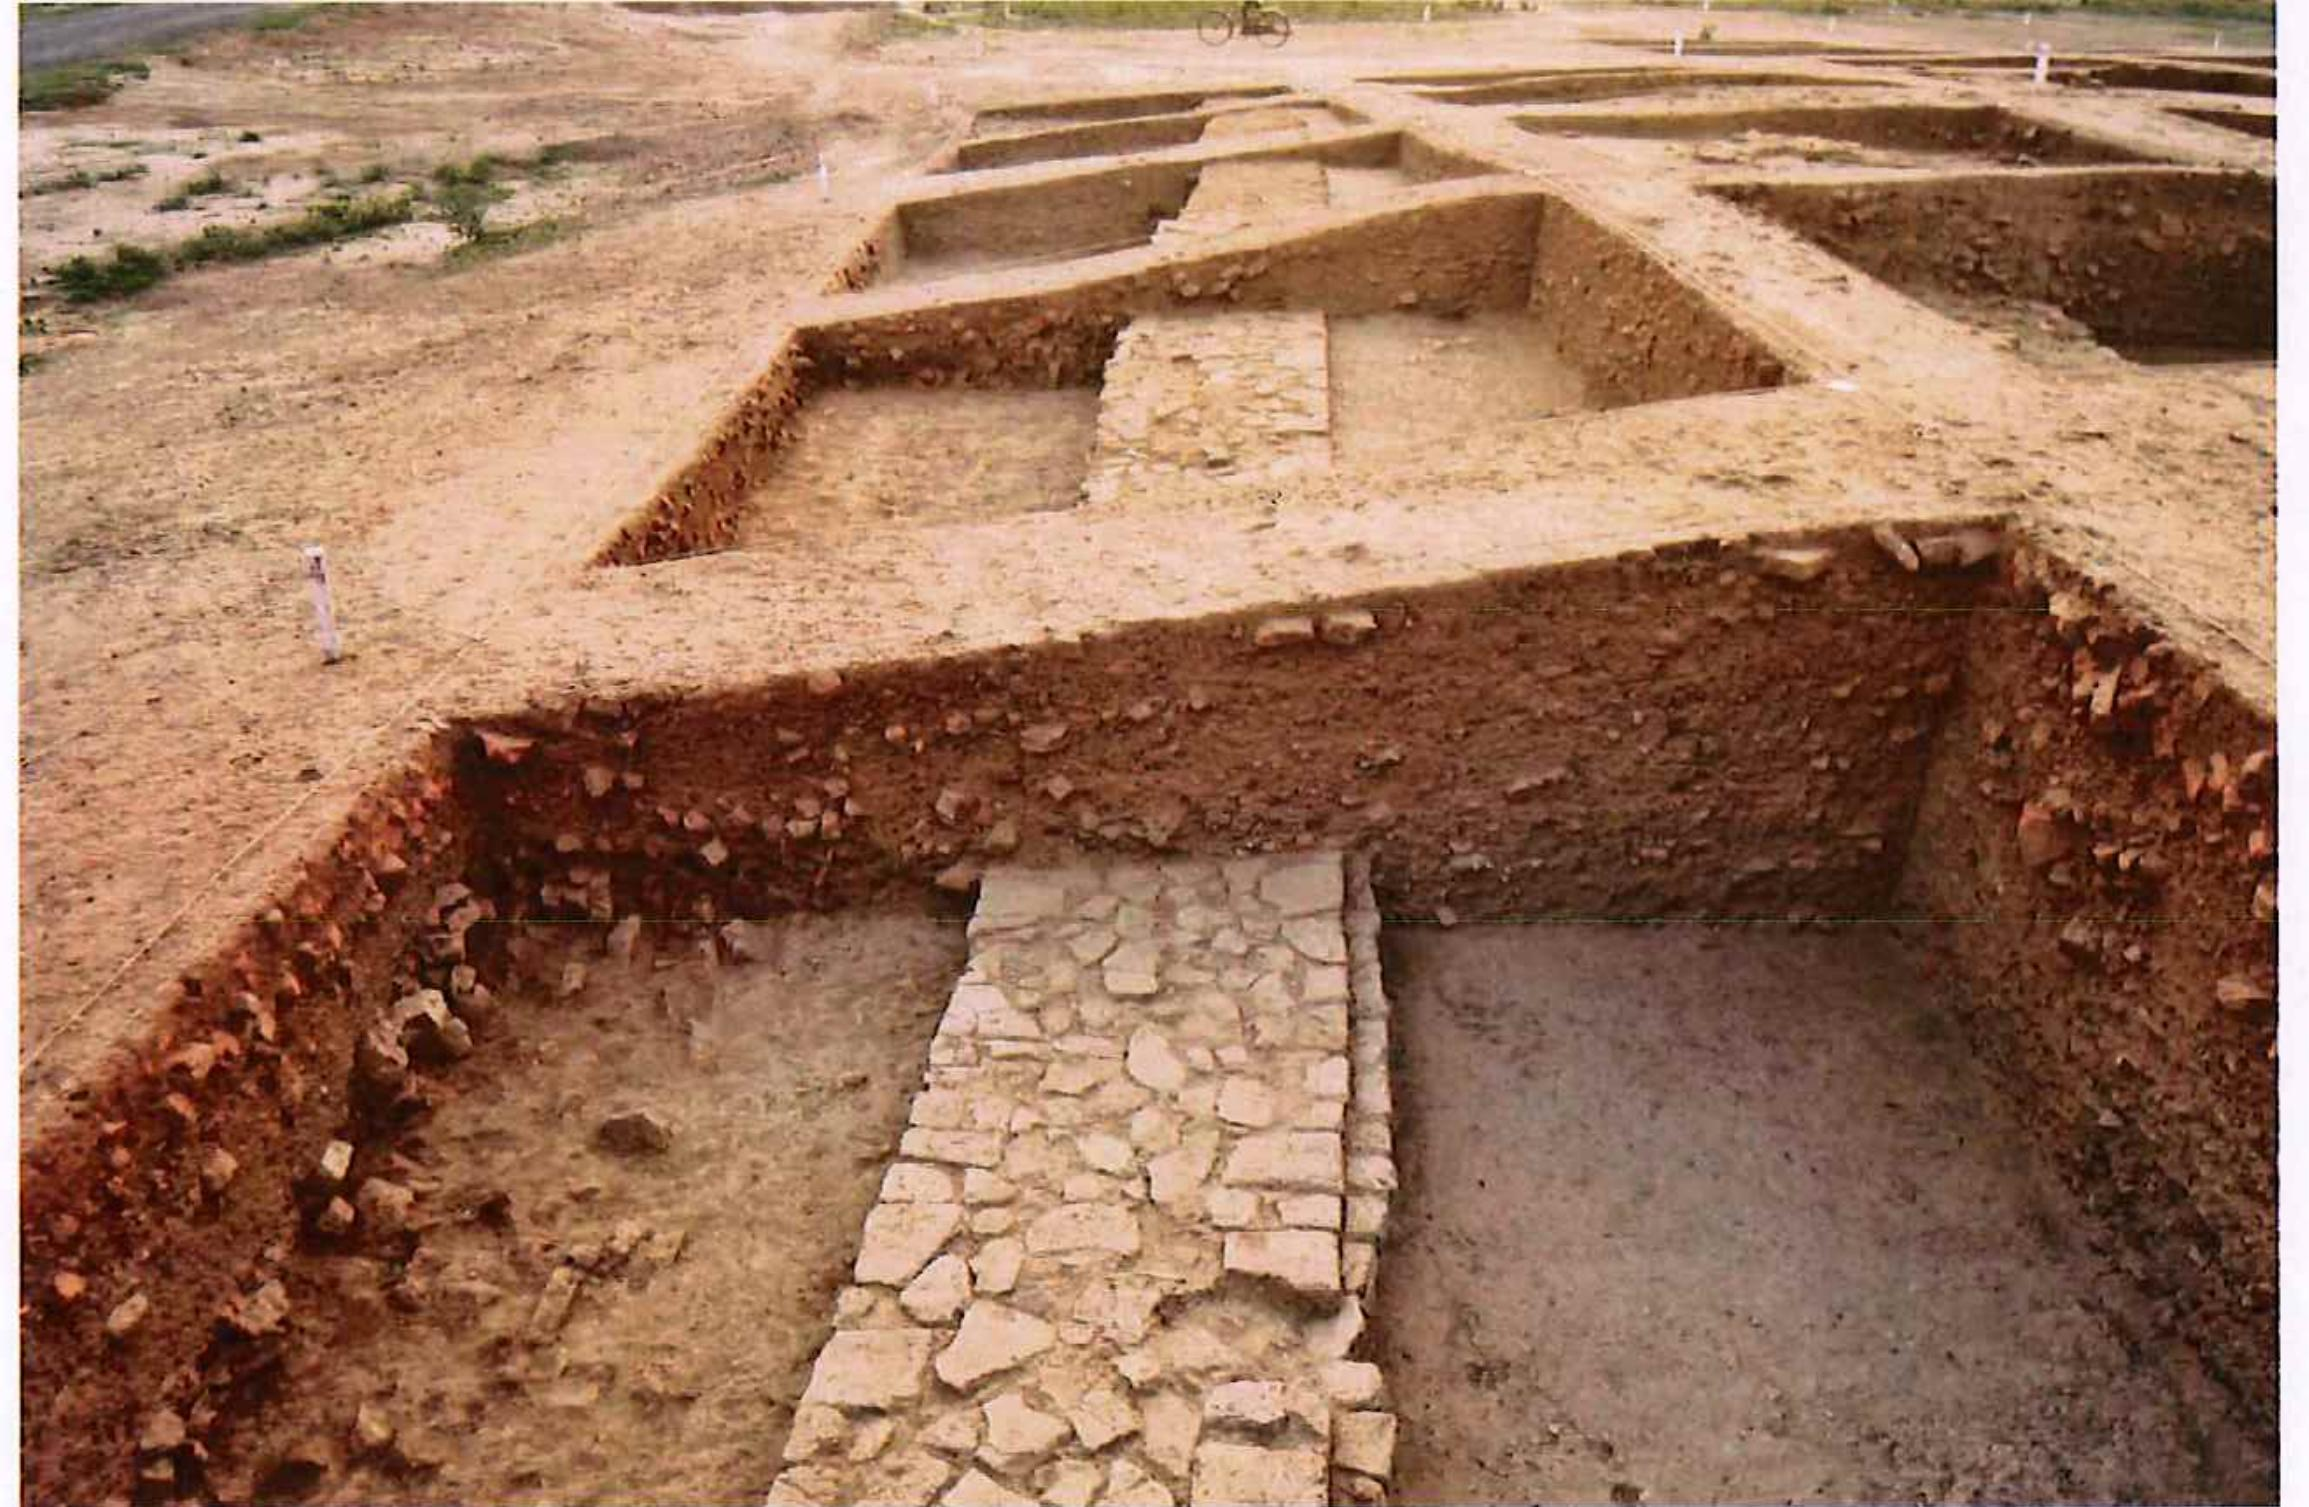

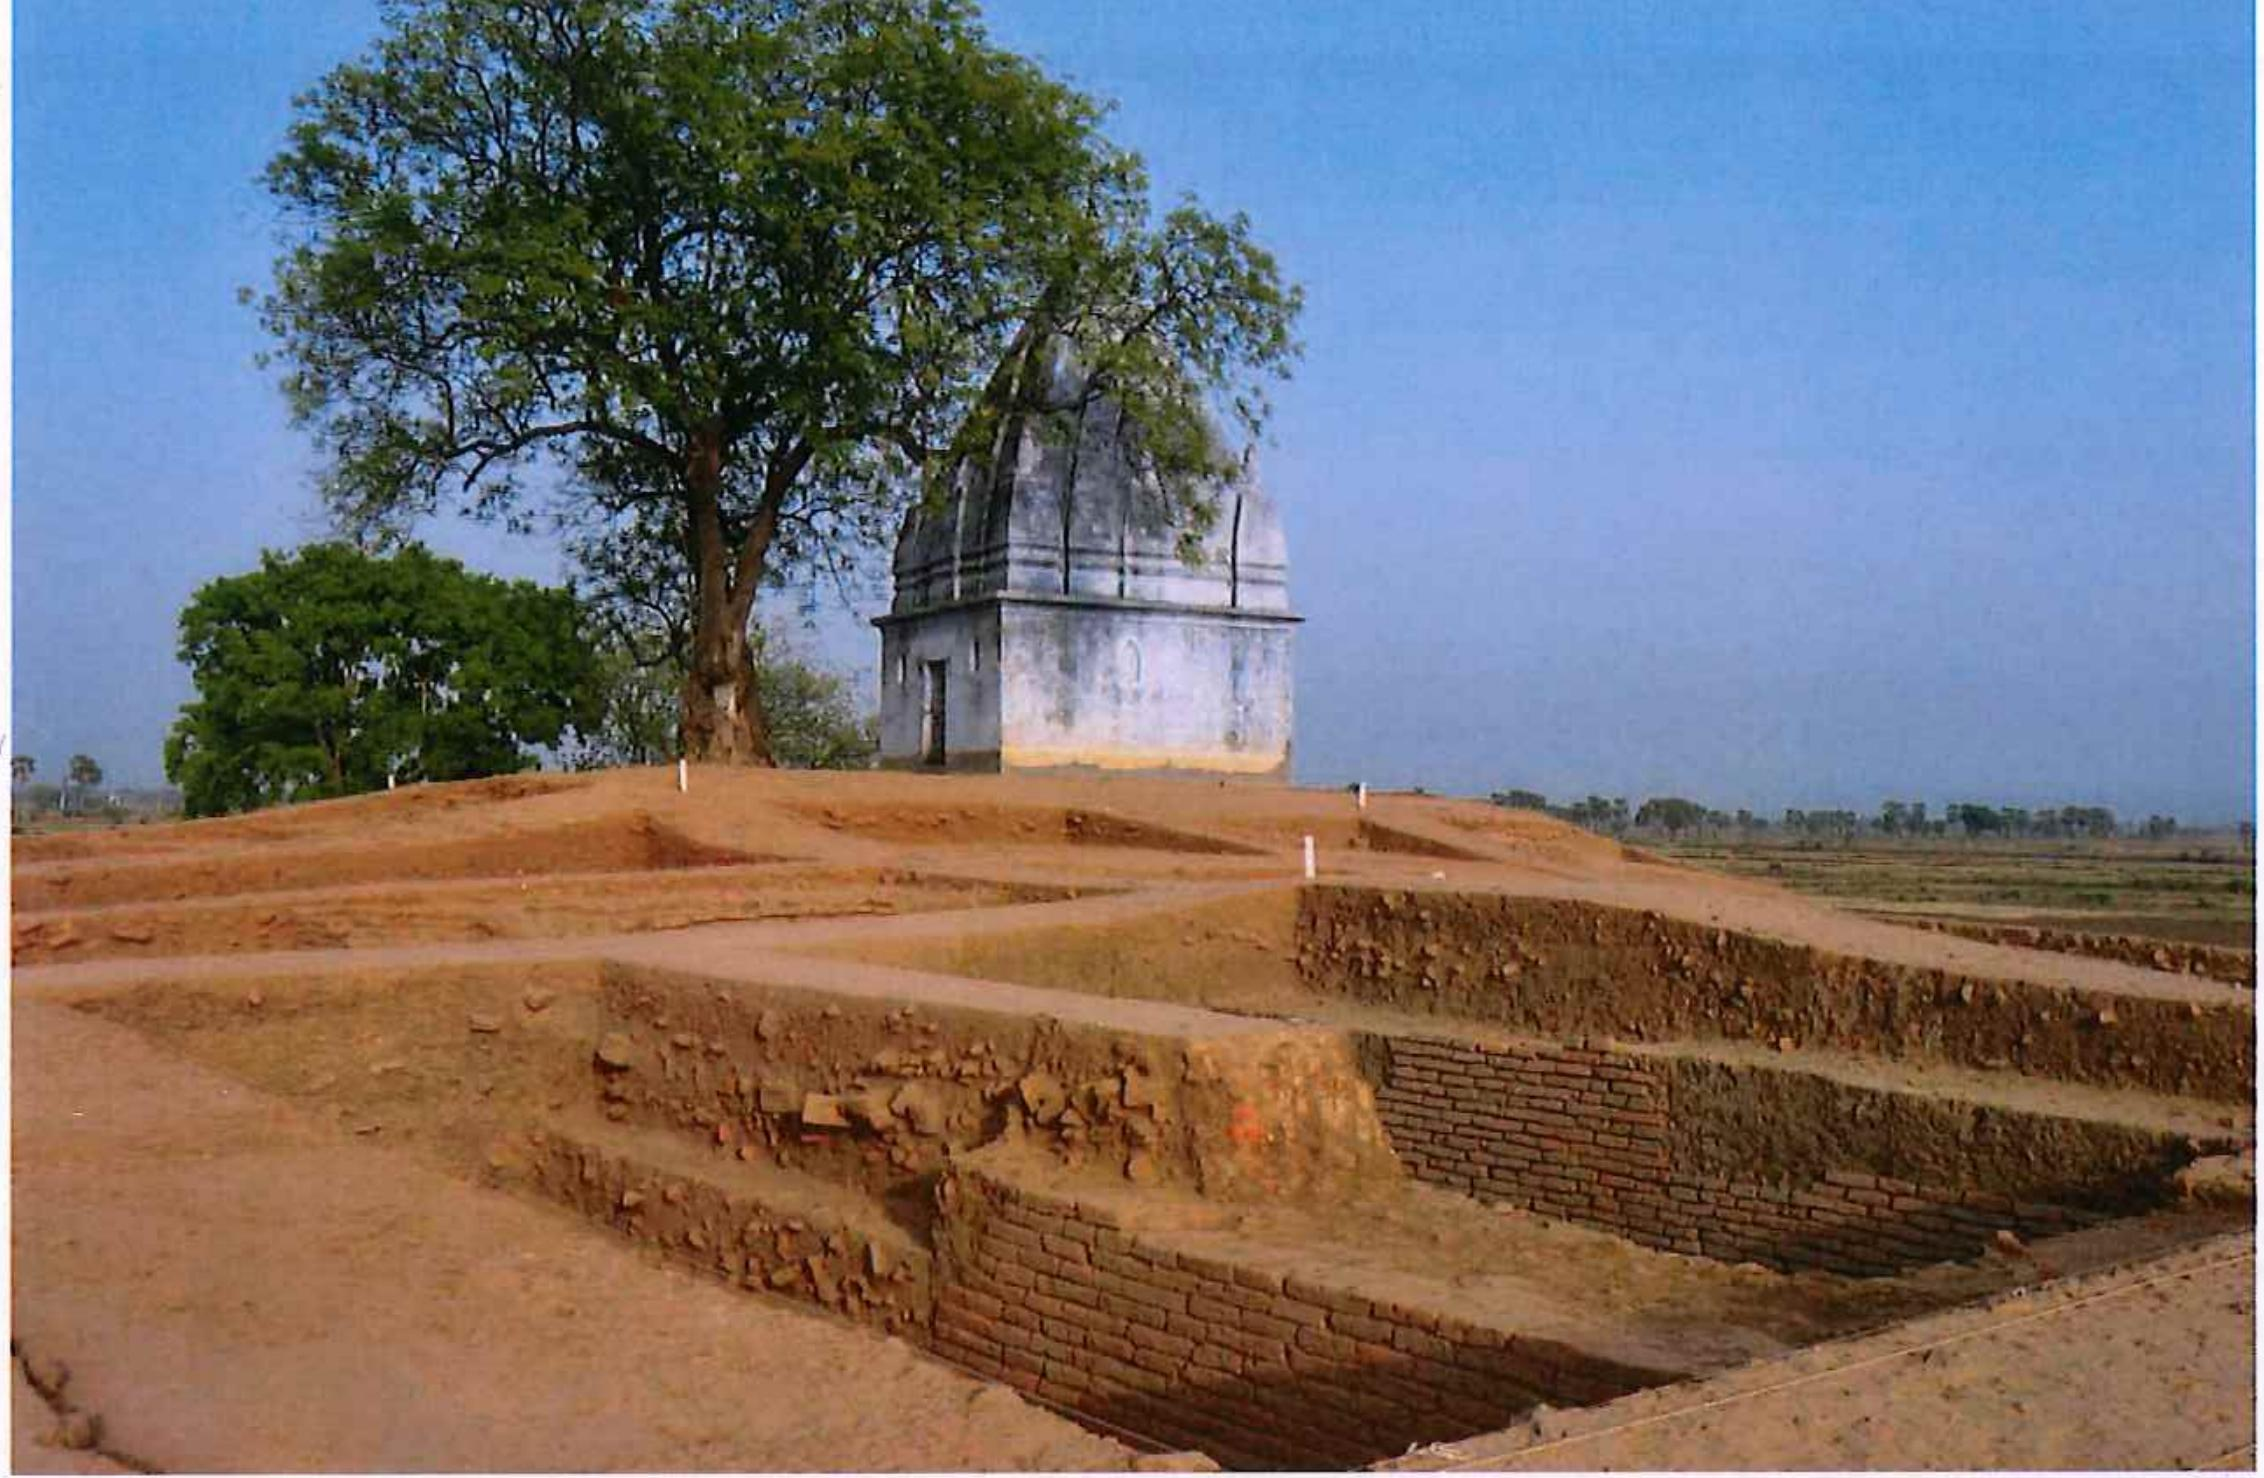

In [58]:
response = chain_with_sources.invoke(
    "What is Sarai Mound ?"
)

print("Response:", response['response'])

print("\n\nContext:")
for text in response['context']['texts']:
    print(text.text)
    print("Page number: ", text.metadata.page_number)
    print("\n" + "-"*50 + "\n")
for image in response['context']['images']:
    display_base64_image(image)

## References

- [LangChain Inspiration](https://github.com/langchain-ai/langchain/blob/master/cookbook/Semi_structured_and_multi_modal_RAG.ipynb?ref=blog.langchain.dev)
- [Multivector Storage](https://python.langchain.com/docs/how_to/multi_vector/)